# Choose Stock & Load Data

In [3]:
import yfinance as yf
import pandas as pd

# Load data
df = yf.download("AAPL", start="2020-01-01", end="2024-01-01")

# Reset index (important for handling date)
df.reset_index(inplace=True)

df.head()

/tmp/ipykernel_1637/803511382.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2020-01-02,72.400528,72.460791,71.156689,71.409793,135480400
1,2020-01-03,71.696632,72.455950,71.472454,71.629138,146322800
2,2020-01-06,72.267944,72.306514,70.568518,70.819216,118387200
3,2020-01-07,71.928032,72.533072,71.708672,72.277555,108872000
4,2020-01-08,73.085091,73.386408,71.631537,71.631537,132079200


# Understand the Data

In [4]:
print(df.shape)

(1006, 6)


In [5]:
print(df.columns)

MultiIndex([(  'Date',     ''),
            ( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1006 entries, 0 to 1005
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   (Date, )        1006 non-null   datetime64[ns]
 1   (Close, AAPL)   1006 non-null   float64       
 2   (High, AAPL)    1006 non-null   float64       
 3   (Low, AAPL)     1006 non-null   float64       
 4   (Open, AAPL)    1006 non-null   float64       
 5   (Volume, AAPL)  1006 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 47.3 KB
None


#### The dataset is time-series in nature, ordered by date. No major missing values were observed so it was ready for modeling.

# Create Target Variable

In [7]:
df['Next_Close'] = df['Close'].shift(-1)

df.dropna(inplace=True)

#### A new column (Next_Close) was created by shifting the closing price to represent the next day’s value. This allows the model

#### to learn and predict future prices.

# Features & Target

In [8]:
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Next_Close']

#### Open, High, Low, and Volume were used as input features as they directly influence stock price movements.

# Train-Test Split (Time Series way)

In [9]:
split = int(len(df) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

#### The dataset was split chronologically into training and testing sets to maintain the time dependency and avoid data leakage.

# Train RandomForest Model

In [10]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)

RandomForestRegressor()

#### A Random Forest Regressor was trained on the dataset. It was chosen because it can capture non-linear patterns in stock

#### price movements.

# Predictions

In [12]:
y_pred = model.predict(X_test)
y_pred

array([151.44050629, 151.12944336, 152.24357727, 157.71950409,
       155.97944809, 159.42347504, 154.59463379, 155.38634552,
       156.61792343, 156.75475403, 158.15221817, 159.72564667,
       158.95267517, 162.61315887, 163.69030182, 163.08506119,
       162.72518829, 162.62843567, 158.83544052, 159.02293961,
       158.95665878, 161.25460434, 163.72764648, 163.53556763,
       165.0174028 , 165.06302582, 165.07203171, 163.18205963,
       163.42454636, 162.91314362, 164.5421254 , 162.84123123,
       164.52759781, 164.48923752, 164.24150192, 166.10119904,
       163.79306488, 170.54077179, 170.92430481, 170.68762482,
       170.77176178, 170.3906189 , 170.58483017, 170.24214432,
       170.97154297, 168.63490219, 170.3616272 , 174.80677582,
       171.14761887, 170.38405457, 167.72438629, 171.10002609,
       170.534832  , 174.24333511, 173.89982971, 174.73912689,
       173.07414124, 172.59483505, 173.45186661, 173.96382385,
       173.91979156, 173.05564758, 173.05564758, 173.05

#### The model generated predictions for the test data estimating the next day’s closing prices.

# Plotting

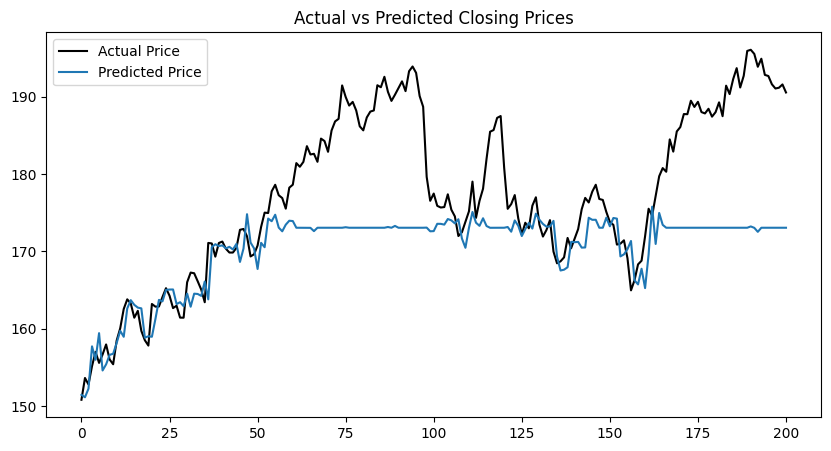

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual Price",color='black')
plt.plot(y_pred, label="Predicted Price")
plt.legend()
plt.title("Actual vs Predicted Closing Prices")
plt.show()

#### The plotted graph of actual vs predicted prices shows that the model follows the overall trend although slight differences exist.

# MAE (Mean Absolute Error)

In [17]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 7.4107691765780475


# MSE (Mean Squared Error)

In [18]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 103.85360054505065


# R² Score

In [19]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.11602328220019686


#### MAE and MSE indicate the prediction error while the R² score shows how well the model explains the variance in stock prices.

# Overall Insight

#### The model performs reasonably well in capturing trends but perfect accuracy is not possible due to the inherent volatility

#### of stock market data.